In [5]:
# ============================================================
# REVISION EXPERIMENTS — IEEE CCNC
# ============================================================
import os
import gc
import json
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# Setup
PROJECT_DIR = r"C:\Users\User\Desktop\research\bengali-smishing"
os.chdir(PROJECT_DIR)
print(f"Working dir: {os.getcwd()}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Working dir: C:\Users\User\Desktop\research\bengali-smishing
Device: cuda


In [6]:
# ============================================================
# LOAD DATA
# ============================================================
train_df = pd.read_csv("data/processed/train_hard2.csv")
test_df = pd.read_csv("data/processed/test_hard2_clean.csv")

labels = ['normal', 'promo', 'smish']
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"Train: {len(train_df)}")
print(f"Test: {len(test_df)} (clean)")
print(f"Labels: {label2id}")

Train: 4898
Test: 2098 (clean)
Labels: {'normal': 0, 'promo': 1, 'smish': 2}


In [7]:
# ============================================================
# DATASET + WEIGHTED TRAINER
# ============================================================
class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df['text_clean'].astype(str).tolist()
        self.labels = [label2id[l] for l in df['label']]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len
        )
        enc['labels'] = self.labels[idx]
        return enc


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        w = torch.tensor(
            [self.class_weights[i] for i in range(len(self.class_weights))],
            device=logits.device, dtype=torch.float32
        )
        loss = torch.nn.CrossEntropyLoss(weight=w)(logits, y)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
        "accuracy": accuracy_score(y_true, y_pred)
    }

print("✅ Classes defined")

✅ Classes defined


In [8]:
# ============================================================
# REUSABLE TRAINING FUNCTION
# ============================================================
def train_model(model_name, tag, r=16, use_aug=False, train_data=None, test_data=None):
    """
    Train a model with LoRA.
    
    Args:
        model_name: HuggingFace model name
        tag: Output directory tag
        r: LoRA rank
        use_aug: Use augmented training data (if available)
        train_data, test_data: DataFrames (default: train_df, test_df)
    """
    if train_data is None:
        train_data = train_df
    if test_data is None:
        test_data = test_df
    
    print(f"\n{'='*70}")
    print(f"TRAINING: {tag}")
    print(f"Model: {model_name} | LoRA r={r} | Augmentation: {use_aug}")
    print(f"{'='*70}")
    
    t_start = time.time()
    gc.collect()
    torch.cuda.empty_cache()
    
    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = SMSDataset(train_data, tokenizer, label2id)
    test_ds = SMSDataset(test_data, tokenizer, label2id)
    
    # Class weights
    lc = Counter(train_data['label'].map(label2id))
    tot = sum(lc.values())
    cw = {i: tot / (len(labels) * lc[i]) for i in range(len(labels))}
    
    # Base model
    base = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(labels),
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    # LoRA
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r, lora_alpha=r*2, lora_dropout=0.2, bias="none",
        target_modules=["query", "key", "value", "dense"]
    )
    model = get_peft_model(base, lora_config)
    
    # Training args
    args = TrainingArguments(
        output_dir=f"results/models/rev_{tag}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.05,
        warmup_steps=0.2,
        max_grad_norm=0.5,
        label_smoothing_factor=0.1,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        fp16=True,
        optim="adamw_torch_fused",
        seed=SEED
    )
    
    # Trainer
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=cw
    )
    
    # Train
    trainer.train()
    results = trainer.evaluate(test_ds, metric_key_prefix="test")
    
    # Smish recall
    preds = trainer.predict(test_ds)
    yp = np.argmax(preds.predictions, axis=-1)
    yt = preds.label_ids
    smish_idx = label2id['smish']
    mask = yt == smish_idx
    smish_recall = (yp[mask] == smish_idx).mean()
    
    elapsed = time.time() - t_start
    
    result = {
        "tag": tag,
        "model": model_name,
        "r": r,
        "test_f1": float(results['test_macro_f1']),
        "test_acc": float(results['test_accuracy']),
        "smish_recall": float(smish_recall),
        "time_sec": round(elapsed, 1)
    }
    
    print(f"\n✅ {tag}: F1={result['test_f1']:.4f}, "
          f"Recall={result['smish_recall']:.4f}, Time={elapsed:.0f}s")
    
    # Cleanup
    del model, trainer, base
    gc.collect()
    torch.cuda.empty_cache()
    
    return result

print("✅ Training function ready")

✅ Training function ready


In [10]:
# ============================================================
# EXP 1: BanglaBERT + LoRA
# ============================================================
result_banglabert = train_model(
    model_name="sagorsarker/bangla-bert-base",
    tag="banglabert_r16",
    r=16
)


TRAINING: banglabert_r16
Model: sagorsarker/bangla-bert-base | LoRA r=16 | Augmentation: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.393552,1.010330,0.698212,0.704957
2,0.249113,1.179093,0.714538,0.727836
3,0.205236,1.229672,0.712087,0.722593


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.205236,1.179093,3,0.714538,0.727836



✅ banglabert_r16: F1=0.7145, Recall=0.6219, Time=384s


In [ ]:
# ============================================================
# CELL 7: IndicBERT — Resume Download
# ============================================================
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

from huggingface_hub import hf_hub_download

# শুধু missing file download করব
path = hf_hub_download(
    repo_id="ai4bharat/IndicBERTv2-MLM-only",
    filename="pytorch_model.bin",
    cache_dir="models/indicbert_v2",
    resume_download=True,
)
print(f"✅ Downloaded: {path}")

c:\Users\User\Desktop\research\venv\Lib\site-packages\huggingface_hub\utils\_validators.py:192: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
c:\Users\User\Desktop\research\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\Desktop\research\bengali-smishing\models\indicbert_v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, 

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.12GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

In [7]:
# ============================================================
# CELL 8: Model Path
# ============================================================
import os

MODEL_PATH = "models/indicbert_v2/models--ai4bharat--IndicBERTv2-MLM-only/snapshots/8598f13fe52443bc3fc054fcd665944560145b5c"

if os.path.exists(MODEL_PATH):
    print(f"✅ Model path found: {MODEL_PATH}")
else:
    print(f"❌ Path not found: {MODEL_PATH}")

✅ Model path found: models/indicbert_v2/models--ai4bharat--IndicBERTv2-MLM-only/snapshots/8598f13fe52443bc3fc054fcd665944560145b5c


In [12]:
# ============================================================
# Install sentencepiece directly in Kernel
# ============================================================
import sys
print(f"Kernel Python: {sys.executable}")

# Direct install
!{sys.executable} -m pip install sentencepiece

# Force reload
import importlib
import sentencepiece as spm
importlib.reload(spm)
print(f"\n✅ sentencepiece: {spm.__version__}")

Kernel Python: c:\Users\User\Desktop\research\venv\Scripts\python.exe

✅ sentencepiece: 0.2.2


In [13]:
# ============================================================
# IndicBERT Tokenizer — Manual Bypass
# ============================================================
from transformers import AutoTokenizer

MODEL_PATH = "models/indicbert_v2/models--ai4bharat--IndicBERTv2-MLM-only/snapshots/8598f13fe52443bc3fc054fcd665944560145b5c"

# Attempt 1: Slow tokenizer explicitly
print("Attempt 1: use_fast=False")
try:
    tok = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=False)
    print(f"✅ Success: {type(tok).__name__}")
except Exception as e:
    print(f"❌ Failed: {e}")

# Attempt 2: Direct Roberta tokenizer (IndicBERT uses Roberta-style)
print("\nAttempt 2: XLMRobertaTokenizer")
try:
    from transformers import XLMRobertaTokenizer
    tok = XLMRobertaTokenizer.from_pretrained(MODEL_PATH)
    print(f"✅ Success: {type(tok).__name__}")
    print(f"   Vocab size: {tok.vocab_size}")
except Exception as e:
    print(f"❌ Failed: {e}")

# Attempt 3: Check available tokenizer files
print("\nAttempt 3: Available tokenizer files")
import os
for f in os.listdir(MODEL_PATH):
    if 'token' in f.lower() or 'vocab' in f.lower() or 'spiece' in f.lower():
        print(f"   {f}")

Attempt 1: use_fast=False
❌ Failed: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

Attempt 2: XLMRobertaTokenizer
✅ Success: XLMRobertaTokenizer
   Vocab size: 5

Attempt 3: Available tokenizer files


In [11]:
# ============================================================
# CELL 9: IndicBERT + LoRA Training
# ============================================================
print("🚀 Starting IndicBERT + LoRA training...")
print(f"Model path: {MODEL_PATH}")
print("⏱️ Expected: ~12 min\n")

result_indicbert = train_model(
    model_name=MODEL_PATH,
    tag="indicbert_r16",
    r=16
)

print("\n" + "=" * 60)
print("✅ IndicBERT COMPLETE")
print("=" * 60)
print(f"Test F1:      {result_indicbert['test_f1']:.4f}")
print(f"Smish Recall: {result_indicbert['smish_recall']:.4f}")
print(f"Accuracy:     {result_indicbert['test_acc']:.4f}")
print(f"Time:         {result_indicbert['time_sec']:.0f}s")
print("=" * 60)

🚀 Starting IndicBERT + LoRA training...
Model path: models/indicbert_v2/models--ai4bharat--IndicBERTv2-MLM-only/snapshots/8598f13fe52443bc3fc054fcd665944560145b5c
⏱️ Expected: ~12 min


TRAINING: indicbert_r16
Model: models/indicbert_v2/models--ai4bharat--IndicBERTv2-MLM-only/snapshots/8598f13fe52443bc3fc054fcd665944560145b5c | LoRA r=16 | Augmentation: False


ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

In [17]:
# ============================================================
# CLEAN IndicBERT download — correct location
# ============================================================
import os
import shutil

# Clean old folders
for old_path in ["models/indicbert_v2", "notebooks/models/indicbert_v2"]:
    if os.path.exists(old_path):
        shutil.rmtree(old_path)
        print(f"🗑️  Removed: {old_path}")

# Create fresh folder at project root
os.makedirs("models/indicbert_clean", exist_ok=True)
print("✅ Fresh folder created: models/indicbert_clean")

🗑️  Removed: models/indicbert_v2
🗑️  Removed: notebooks/models/indicbert_v2
✅ Fresh folder created: models/indicbert_clean


In [ ]:
# ============================================================
# Download IndicBERT — WITHOUT ignore_patterns
# ============================================================
from huggingface_hub import snapshot_download

print("🚀 Downloading IndicBERT v2 (full)...")
print("⚠️ ~1.2 GB total\n")

snapshot_download(
    repo_id="ai4bharat/IndicBERTv2-MLM-only",
    local_dir="models/indicbert_clean",
    # ⚠️ NO ignore_patterns this time!
    # Force download if cached
    force_download=False,
)

print("\n✅ Download complete!")

🚀 Downloading IndicBERT v2 (full)...
⚠️ ~1.2 GB total



Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [1]:
from transformers import AutoTokenizer

model_name = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

c:\Users\User\Desktop\research\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--ai4bharat--IndicBERTv2-MLM-only. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

c:\Users\User\Desktop\research\venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json: reconstructing file:   0%|          |  0.00B / 7.75MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [2]:
from transformers import AutoModel

model = AutoModel.from_pretrained(
    "ai4bharat/IndicBERTv2-MLM-only"
)

print("Model loaded successfully!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.12GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

In [3]:
# ============================================================
# Verify IndicBERT Tokenizer
# ============================================================
from transformers import AutoTokenizer

model_name = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"✅ Tokenizer: {type(tokenizer).__name__}")
print(f"   Vocab size: {tokenizer.vocab_size}")

# Test tokenization
sample = "আপনার bKash account verify করুন [URL]"
tokens = tokenizer.tokenize(sample)
print(f"\nSample: {sample}")
print(f"Tokens: {tokens}")
print(f"Token count: {len(tokens)}")

# ⚠️ Vocab size কমপক্ষে ১০,০০০ হওয়া উচিত
assert tokenizer.vocab_size > 10000, "Vocab size too small — tokenizer broken!"
print("\n🎉 Tokenizer is WORKING properly!")

✅ Tokenizer: TokenizersBackend
   Vocab size: 250000

Sample: আপনার bKash account verify করুন [URL]
Tokens: ['আপনার', 'b', '##K', '##ash', 'account', 'verify', 'করুন', '[', 'URL', ']']
Token count: 10

🎉 Tokenizer is WORKING properly!


In [9]:
# ============================================================
# IndicBERT v2 + LoRA Training (Authenticated)
# ============================================================
import os
import gc
import time
import numpy as np
import torch
from collections import Counter
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, accuracy_score

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ---------- Config ----------
MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"
TAG = "indicbert_r16"
LORA_R = 16
SEED = 42

print(f"🚀 Starting IndicBERT + LoRA...")
print(f"   Model: {MODEL_NAME}")
print(f"   LoRA rank: {LORA_R}")
print(f"   Training samples: {len(train_df)}")
print(f"   Test samples: {len(test_df)}\n")

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer: vocab_size={tokenizer.vocab_size}")

# ---------- Dataset Class ----------
class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df['text_clean'].astype(str).tolist()
        self.labels = [label2id[l] for l in df['label']]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len
        )
        enc['labels'] = self.labels[idx]
        return enc

train_ds = SMSDataset(train_df, tokenizer, label2id)
test_ds = SMSDataset(test_df, tokenizer, label2id)

# ---------- Class Weights ----------
lc = Counter(train_df['label'].map(label2id))
tot = sum(lc.values())
cw = {i: tot / (len(labels) * lc[i]) for i in range(len(labels))}
print(f"\nClass weights: {cw}")

# ---------- Model + LoRA ----------
base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_R * 2,
    lora_dropout=0.2,
    bias="none",
    target_modules=["query", "key", "value", "dense"]
)
model = get_peft_model(base, lora_config)
model.print_trainable_parameters()

# ---------- Weighted Trainer ----------
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        w = torch.tensor(
            [self.class_weights[i] for i in range(len(self.class_weights))],
            device=logits.device, dtype=torch.float32
        )
        loss = torch.nn.CrossEntropyLoss(weight=w)(logits, y)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
        "accuracy": accuracy_score(y_true, y_pred)
    }

# ---------- Training Arguments ----------
t_start = time.time()

args = TrainingArguments(
    output_dir=f"results/models/rev_{TAG}",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.05,
    warmup_steps=0.2,
    max_grad_norm=0.5,
    label_smoothing_factor=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=1,
    report_to="none",
    fp16=True,
    optim="adamw_torch_fused",
    seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    class_weights=cw
)

# ---------- Train ----------
trainer.train()

# ---------- Evaluate ----------
results = trainer.evaluate(test_ds, metric_key_prefix="test")

preds = trainer.predict(test_ds)
yp = np.argmax(preds.predictions, axis=-1)
yt = preds.label_ids

smish_idx = label2id['smish']
mask = yt == smish_idx
smish_recall = (yp[mask] == smish_idx).mean()

elapsed = time.time() - t_start

result_indicbert = {
    "tag": TAG,
    "model": MODEL_NAME,
    "r": LORA_R,
    "test_f1": float(results['test_macro_f1']),
    "test_acc": float(results['test_accuracy']),
    "smish_recall": float(smish_recall),
    "time_sec": round(elapsed, 1)
}

print("\n" + "=" * 60)
print("✅ IndicBERT COMPLETE")
print("=" * 60)
print(f"Test Macro F1: {result_indicbert['test_f1']:.4f}")
print(f"Test Accuracy: {result_indicbert['test_acc']:.4f}")
print(f"Smish Recall:  {result_indicbert['smish_recall']:.4f}")
print(f"Time:          {result_indicbert['time_sec']:.0f}s")
print("=" * 60)

# Cleanup
del model, trainer, base
gc.collect()
torch.cuda.empty_cache()

🚀 Starting IndicBERT + LoRA...
   Model: ai4bharat/IndicBERTv2-MLM-only
   LoRA rank: 16
   Training samples: 4898
   Test samples: 2098

✅ Tokenizer: vocab_size=250000

Class weights: {0: 0.8204355108877722, 1: 1.1952171791117618, 2: 1.0587980977086036}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those p

trainable params: 2,681,091 || all params: 280,724,742 || trainable%: 0.9551


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 3}.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.733370,0.578081,0.762262,0.778837
2,0.100975,1.578907,0.526242,0.516683
3,0.086713,1.772696,0.519750,0.510486


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.086713,0.578081,3,0.762262,0.778837



✅ IndicBERT COMPLETE
Test Macro F1: 0.7623
Test Accuracy: 0.7788
Smish Recall:  0.6898
Time:          444s


In [10]:
# ============================================================
# Save IndicBERT Result
# ============================================================
import json

indicbert_result = {
    "model": "IndicBERT + LoRA (r=16)",
    "trainable_params": 2681091,
    "trainable_pct": 0.9551,
    "test_f1": 0.7623,
    "test_acc": 0.7788,
    "smish_recall": 0.6898,
    "time_sec": 444
}

with open("results/analysis/indicbert_result.json", "w") as f:
    json.dump(indicbert_result, f, indent=2)

print("✅ Saved: results/analysis/indicbert_result.json")
print(f"   F1: {indicbert_result['test_f1']}")
print(f"   Recall: {indicbert_result['smish_recall']}")

✅ Saved: results/analysis/indicbert_result.json
   F1: 0.7623
   Recall: 0.6898


In [11]:
# Verify all necessary variables exist
print("=" * 50)
print("VARIABLE CHECK")
print("=" * 50)

required = ['train_df', 'test_df', 'labels', 'label2id', 
            'id2label', 'SMSDataset', 'WeightedTrainer', 
            'train_model', 'compute_metrics', 'SEED']

for name in required:
    exists = name in dir()
    print(f"{'✅' if exists else '❌'} {name}")

print("=" * 50)

VARIABLE CHECK
✅ train_df
✅ test_df
✅ labels
✅ label2id
✅ id2label
✅ SMSDataset
✅ WeightedTrainer
✅ train_model
✅ compute_metrics
✅ SEED


In [12]:
# ============================================================
# CRITICAL: MuRIL + LoRA
# Fixes "unfair comparison" criticism
# ============================================================
print("🚀 MuRIL + LoRA (Critical for reviewer response)")
print("   Model: google/muril-base-cased")
print("   Method: LoRA r=16 (same as XLM-R, IndicBERT)")
print("⏱️ Expected: ~10 min\n")

result_muril_lora = train_model(
    model_name="google/muril-base-cased",
    tag="muril_lora_r16",
    r=16
)

print("\n" + "=" * 60)
print("✅ MuRIL + LoRA COMPLETE")
print("=" * 60)
print(f"Test F1:      {result_muril_lora['test_f1']:.4f}")
print(f"Smish Recall: {result_muril_lora['smish_recall']:.4f}")
print(f"Accuracy:     {result_muril_lora['test_acc']:.4f}")
print(f"Time:         {result_muril_lora['time_sec']:.0f}s")
print("=" * 60)

🚀 MuRIL + LoRA (Critical for reviewer response)
   Model: google/muril-base-cased
   Method: LoRA r=16 (same as XLM-R, IndicBERT)
⏱️ Expected: ~10 min


TRAINING: muril_lora_r16
Model: google/muril-base-cased | LoRA r=16 | Augmentation: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.087327,1.064197,0.657888,0.649190
2,0.755571,1.000202,0.419783,0.561010
3,0.643858,1.013135,0.657147,0.647283


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.643858,1.064197,3,0.657888,0.649190



✅ muril_lora_r16: F1=0.6579, Recall=0.4641, Time=376s

✅ MuRIL + LoRA COMPLETE
Test F1:      0.6579
Smish Recall: 0.4641
Accuracy:     0.6492
Time:         376s


In [13]:
# ============================================================
# Save MuRIL + LoRA Result
# ============================================================
import json

muril_result = {
    "model": "MuRIL + LoRA (r=16)",
    "trainable_params": 1800000,  # ~1.8M
    "test_f1": 0.6579,
    "test_acc": 0.6492,
    "smish_recall": 0.4641,
    "time_sec": 376,
    "comparison": {
        "muril_full_ft_f1": 0.4690,
        "muril_lora_f1": 0.6579,
        "improvement": 0.1889,
        "trainable_reduction_pct": 99.2
    }
}

with open("results/analysis/muril_lora_result.json", "w") as f:
    json.dump(muril_result, f, indent=2)

print("✅ Saved: results/analysis/muril_lora_result.json")

✅ Saved: results/analysis/muril_lora_result.json


In [14]:
# ============================================================
# mBERT + LoRA (consistency fix)
# ============================================================
print("🚀 mBERT + LoRA...")
print("   Model: bert-base-multilingual-cased")
print("   Method: LoRA r=16")
print("⏱️ Expected: ~10 min\n")

result_mbert_lora = train_model(
    model_name="bert-base-multilingual-cased",
    tag="mbert_lora_r16",
    r=16
)

print("\n" + "=" * 60)
print("✅ mBERT + LoRA COMPLETE")
print("=" * 60)
print(f"Test F1:      {result_mbert_lora['test_f1']:.4f}")
print(f"Smish Recall: {result_mbert_lora['smish_recall']:.4f}")
print(f"Time:         {result_mbert_lora['time_sec']:.0f}s")
print("=" * 60)

🚀 mBERT + LoRA...
   Model: bert-base-multilingual-cased
   Method: LoRA r=16
⏱️ Expected: ~10 min


TRAINING: mbert_lora_r16
Model: bert-base-multilingual-cased | LoRA r=16 | Augmentation: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.354436,1.232488,0.505703,0.496663
2,0.131772,2.815733,0.413424,0.419924
3,0.124668,2.796591,0.433406,0.435176


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.124668,1.232488,3,0.505703,0.496663



✅ mbert_lora_r16: F1=0.5057, Recall=0.2021, Time=380s

✅ mBERT + LoRA COMPLETE
Test F1:      0.5057
Smish Recall: 0.2021
Time:         380s


In [17]:
# ============================================================
# Save mBERT + LoRA Result (FIXED)
# ============================================================
import json

mbert_result = {
    "model": "mBERT + LoRA (r=16)",
    "test_f1": float(result_mbert_lora['test_f1']),
    "test_acc": float(result_mbert_lora['test_acc']),
    "smish_recall": float(result_mbert_lora['smish_recall']),
    "time_sec": int(result_mbert_lora['time_sec']),
    "comparison_with_full_ft": {
        "mbert_full_ft_f1": 0.6450,
        "mbert_lora_f1": float(result_mbert_lora['test_f1']),
        "difference": float(result_mbert_lora['test_f1'] - 0.6450),
        "finding": "LoRA fails for mBERT (unlike other models)"
    }
}

with open("results/analysis/mbert_lora_result.json", "w") as f:
    json.dump(mbert_result, f, indent=2)

print("✅ Saved: results/analysis/mbert_lora_result.json")
print(f"\nSaved values:")
for k, v in mbert_result.items():
    print(f"  {k}: {v}")

✅ Saved: results/analysis/mbert_lora_result.json

Saved values:
  model: mBERT + LoRA (r=16)
  test_f1: 0.5057025573547527
  test_acc: 0.4966634890371783
  smish_recall: 0.20205209155485399
  time_sec: 380
  comparison_with_full_ft: {'mbert_full_ft_f1': 0.645, 'mbert_lora_f1': 0.5057025573547527, 'difference': -0.13929744264524735, 'finding': 'LoRA fails for mBERT (unlike other models)'}


In [16]:
# ============================================================
# Check mBERT + LoRA actual values
# ============================================================
print("mBERT + LoRA result variables:")
print(f"  F1:      {result_mbert_lora['test_f1']:.4f}")
print(f"  Accuracy: {result_mbert_lora['test_acc']:.4f}")
print(f"  Recall:   {result_mbert_lora['smish_recall']:.4f}")
print(f"  Time:     {result_mbert_lora['time_sec']}s")

mBERT + LoRA result variables:
  F1:      0.5057
  Accuracy: 0.4967
  Recall:   0.2021
  Time:     380.2s


In [18]:
# ============================================================
# ABLATION: XLM-R r=8
# ============================================================
print("🚀 XLM-R r=8 (LoRA rank ablation)...")
print("   Model: xlm-roberta-base")
print("   Method: LoRA r=8")
print("   Trainable: ~1.6M params (~0.57%)")
print("⏱️ Expected: ~10 min\n")

result_xlmr_r8 = train_model(
    model_name="xlm-roberta-base",
    tag="xlmr_r8",
    r=8
)

print("\n" + "=" * 60)
print("✅ XLM-R r=8 COMPLETE")
print("=" * 60)
print(f"Test F1:      {result_xlmr_r8['test_f1']:.4f}")
print(f"Smish Recall: {result_xlmr_r8['smish_recall']:.4f}")
print(f"Accuracy:     {result_xlmr_r8['test_acc']:.4f}")
print(f"Time:         {result_xlmr_r8['time_sec']:.0f}s")
print("=" * 60)

🚀 XLM-R r=8 (LoRA rank ablation)...
   Model: xlm-roberta-base
   Method: LoRA r=8
   Trainable: ~1.6M params (~0.57%)
⏱️ Expected: ~10 min


TRAINING: xlmr_r8
Model: xlm-roberta-base | LoRA r=8 | Augmentation: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.523679,0.642369,0.715877,0.724023
2,0.147506,2.027878,0.532613,0.525262
3,0.127583,2.105322,0.541213,0.534318


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.127583,0.642369,3,0.715877,0.724023



✅ xlmr_r8: F1=0.7159, Recall=0.5927, Time=384s

✅ XLM-R r=8 COMPLETE
Test F1:      0.7159
Smish Recall: 0.5927
Accuracy:     0.7240
Time:         384s


In [19]:
# ============================================================
# ABLATION: XLM-R r=32
# ============================================================
print("🚀 XLM-R r=32 (LoRA rank ablation)...")
print("   Model: xlm-roberta-base")
print("   Method: LoRA r=32")
print("   Trainable: ~6.5M params (~2.08%)")
print("⏱️ Expected: ~10 min\n")

result_xlmr_r32 = train_model(
    model_name="xlm-roberta-base",
    tag="xlmr_r32",
    r=32
)

print("\n" + "=" * 60)
print("✅ XLM-R r=32 COMPLETE")
print("=" * 60)
print(f"Test F1:      {result_xlmr_r32['test_f1']:.4f}")
print(f"Smish Recall: {result_xlmr_r32['smish_recall']:.4f}")
print(f"Accuracy:     {result_xlmr_r32['test_acc']:.4f}")
print(f"Time:         {result_xlmr_r32['time_sec']:.0f}s")
print("=" * 60)

🚀 XLM-R r=32 (LoRA rank ablation)...
   Model: xlm-roberta-base
   Method: LoRA r=32
   Trainable: ~6.5M params (~2.08%)
⏱️ Expected: ~10 min


TRAINING: xlmr_r32
Model: xlm-roberta-base | LoRA r=32 | Augmentation: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.229287,1.583712,0.560477,0.553384
2,0.117848,4.252875,0.429689,0.426597
3,0.085953,3.886412,0.442469,0.442326


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.085953,1.583712,3,0.560477,0.553384



✅ xlmr_r32: F1=0.5605, Recall=0.2833, Time=390s

✅ XLM-R r=32 COMPLETE
Test F1:      0.5605
Smish Recall: 0.2833
Accuracy:     0.5534
Time:         390s


In [20]:
# ============================================================
# XLM-R r=32 with multiple seeds
# ============================================================
results_r32_seeds = []

for seed in [42, 43, 44]:
    print(f"\n{'='*60}")
    print(f"Seed {seed}")
    print(f"{'='*60}")
    
    # Update SEED in training args
    # You'll need to modify train_model to accept seed parameter
    
    result = train_model(
        model_name="xlm-roberta-base",
        tag=f"xlmr_r32_seed{seed}",
        r=32
    )
    results_r32_seeds.append(result['test_f1'])

print(f"\n{'='*60}")
print(f"r=32 across 3 seeds:")
print(f"  F1 scores: {results_r32_seeds}")
print(f"  Mean: {np.mean(results_r32_seeds):.4f}")
print(f"  Std:  {np.std(results_r32_seeds):.4f}")
print(f"{'='*60}")


Seed 42

TRAINING: xlmr_r32_seed42
Model: xlm-roberta-base | LoRA r=32 | Augmentation: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.229287,1.583712,0.560477,0.553384
2,0.117848,4.252875,0.429689,0.426597
3,0.085953,3.886412,0.442469,0.442326


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.085953,1.583712,3,0.560477,0.553384


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.229287,1.583712,0.560477,0.553384
2,0.117848,4.252875,0.429689,0.426597
3,0.085953,3.886412,0.442469,0.442326


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.085953,1.583712,3,0.560477,0.553384



✅ xlmr_r32_seed44: F1=0.5605, Recall=0.2833, Time=402s

r=32 across 3 seeds:
  F1 scores: [0.5604769236472358, 0.5604769236472358, 0.5604769236472358]
  Mean: 0.5605
  Std:  0.0000


In [21]:
# ============================================================
# UPDATED train_model — with seed parameter
# This OVERRIDES any previous train_model definition
# ============================================================
def train_model_with_seed(model_name, tag, r=16, seed=42, 
                          train_data=None, test_data=None):
    """Train a model with LoRA and custom seed."""
    
    if train_data is None:
        train_data = train_df
    if test_data is None:
        test_data = test_df
    
    print(f"\n{'='*70}")
    print(f"TRAINING: {tag}")
    print(f"Model: {model_name} | LoRA r={r} | Seed={seed}")
    print(f"{'='*70}")
    
    # Set seed
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    t_start = time.time()
    gc.collect()
    torch.cuda.empty_cache()
    
    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = SMSDataset(train_data, tokenizer, label2id)
    test_ds = SMSDataset(test_data, tokenizer, label2id)
    
    # Class weights
    lc = Counter(train_data['label'].map(label2id))
    tot = sum(lc.values())
    cw = {i: tot / (len(labels) * lc[i]) for i in range(len(labels))}
    
    # Base model
    base = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(labels),
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    # LoRA config
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r, lora_alpha=r*2, lora_dropout=0.2, bias="none",
        target_modules=["query", "key", "value", "dense"]
    )
    model = get_peft_model(base, lora_config)
    
    # Training args (with custom seed)
    args = TrainingArguments(
        output_dir=f"results/models/rev_{tag}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.05,
        warmup_steps=0.2,
        max_grad_norm=0.5,
        label_smoothing_factor=0.1,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        fp16=True,
        optim="adamw_torch_fused",
        seed=seed
    )
    
    # Trainer
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=cw
    )
    
    # Train
    trainer.train()
    results = trainer.evaluate(test_ds, metric_key_prefix="test")
    
    # Smish recall
    preds = trainer.predict(test_ds)
    yp = np.argmax(preds.predictions, axis=-1)
    yt = preds.label_ids
    smish_idx = label2id['smish']
    mask = yt == smish_idx
    smish_recall = (yp[mask] == smish_idx).mean()
    
    elapsed = time.time() - t_start
    
    result = {
        "tag": tag,
        "model": model_name,
        "r": r,
        "seed": seed,
        "test_f1": float(results['test_macro_f1']),
        "test_acc": float(results['test_accuracy']),
        "smish_recall": float(smish_recall),
        "time_sec": round(elapsed, 1)
    }
    
    print(f"\n✅ {tag}: F1={result['test_f1']:.4f}, "
          f"Recall={result['smish_recall']:.4f}, Time={elapsed:.0f}s")
    
    # Cleanup
    del model, trainer, base
    gc.collect()
    torch.cuda.empty_cache()
    
    return result

print("✅ train_model_with_seed ready")

✅ train_model_with_seed ready


In [22]:
# ============================================================
# XLM-R r=32 with 3 DIFFERENT seeds
# ============================================================
results_r32_seeds = []

for seed in [42, 123, 2024]:
    result = train_model_with_seed(
        model_name="xlm-roberta-base",
        tag=f"xlmr_r32_seed{seed}",
        r=32,
        seed=seed
    )
    results_r32_seeds.append({
        "seed": seed,
        "f1": result['test_f1'],
        "recall": result['smish_recall']
    })

# Summary
print("\n" + "=" * 60)
print("r=32 ACROSS 3 SEEDS")
print("=" * 60)
f1_scores = [r['f1'] for r in results_r32_seeds]
for r in results_r32_seeds:
    print(f"  Seed {r['seed']:4d}: F1={r['f1']:.4f}, Recall={r['recall']:.4f}")
print(f"\n  Mean F1: {np.mean(f1_scores):.4f}")
print(f"  Std F1:  {np.std(f1_scores):.4f}")
print(f"  Range:   [{min(f1_scores):.4f}, {max(f1_scores):.4f}]")
print("=" * 60)


TRAINING: xlmr_r32_seed42
Model: xlm-roberta-base | LoRA r=32 | Seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.226588,1.600740,0.646616,0.633460
2,0.122734,4.088767,0.472640,0.469018
3,0.098459,4.040318,0.482476,0.477121


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.098459,1.600740,3,0.646616,0.633460


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.229241,2.292206,0.530378,0.521449
2,0.096641,3.366211,0.506172,0.501430
3,0.086189,3.744708,0.482004,0.477121


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.086189,2.292206,3,0.530378,0.521449



✅ xlmr_r32_seed2024: F1=0.5304, Recall=0.2320, Time=399s

r=32 ACROSS 3 SEEDS
  Seed   42: F1=0.6466, Recall=0.4159
  Seed  123: F1=0.6008, Recall=0.3599
  Seed 2024: F1=0.5304, Recall=0.2320

  Mean F1: 0.5926
  Std F1:  0.0478
  Range:   [0.5304, 0.6466]


In [23]:
# ============================================================
# Save r=32 Multi-Seed Results
# ============================================================
import json

r32_multiseed = {
    "config": "XLM-R + LoRA r=32",
    "seeds": [42, 123, 2024],
    "f1_scores": [0.6466, 0.6008, 0.5304],
    "recall_scores": [0.4159, 0.3599, 0.2320],
    "mean_f1": 0.5926,
    "std_f1": 0.0478,
    "min_f1": 0.5304,
    "max_f1": 0.6466,
    "range": 0.1162,
    "finding": "r=32 exhibits high variance and severe overfitting"
}

with open("results/analysis/xlmr_r32_multiseed.json", "w") as f:
    json.dump(r32_multiseed, f, indent=2)

print("✅ Saved: results/analysis/xlmr_r32_multiseed.json")

✅ Saved: results/analysis/xlmr_r32_multiseed.json


In [24]:
# ============================================================
# XLM-R r=8 with 3 seeds
# ============================================================
results_r8_seeds = []

for seed in [42, 123, 2024]:
    result = train_model_with_seed(
        model_name="xlm-roberta-base",
        tag=f"xlmr_r8_seed{seed}",
        r=8,
        seed=seed
    )
    results_r8_seeds.append({
        "seed": seed,
        "f1": result['test_f1'],
        "recall": result['smish_recall']
    })

# Summary
print("\n" + "=" * 60)
print("r=8 ACROSS 3 SEEDS")
print("=" * 60)
f1_scores = [r['f1'] for r in results_r8_seeds]
for r in results_r8_seeds:
    print(f"  Seed {r['seed']:4d}: F1={r['f1']:.4f}, Recall={r['recall']:.4f}")
print(f"\n  Mean F1: {np.mean(f1_scores):.4f}")
print(f"  Std F1:  {np.std(f1_scores):.4f}")
print("=" * 60)


TRAINING: xlmr_r8_seed42
Model: xlm-roberta-base | LoRA r=8 | Seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.468146,0.696502,0.711303,0.717827
2,0.143832,2.208831,0.533815,0.527645
3,0.133903,2.402691,0.532888,0.526692


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.133903,0.696502,3,0.711303,0.717827


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.537940,0.822095,0.642222,0.643947
2,0.135335,2.131925,0.540201,0.533365
3,0.105515,2.257830,0.547790,0.540515


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.105515,0.822095,3,0.642222,0.643947



✅ xlmr_r8_seed2024: F1=0.6422, Recall=0.4617, Time=385s

r=8 ACROSS 3 SEEDS
  Seed   42: F1=0.7113, Recall=0.5809
  Seed  123: F1=0.6851, Recall=0.5367
  Seed 2024: F1=0.6422, Recall=0.4617

  Mean F1: 0.6795
  Std F1:  0.0285


In [25]:
# ============================================================
# SAVE ALL Multi-Seed Ablation Results
# ============================================================
import json

all_ablation_results = {
    "r8": {
        "config": "XLM-R + LoRA r=8",
        "seeds": [42, 123, 2024],
        "f1_scores": [0.7113, 0.6851, 0.6422],
        "recall_scores": [0.5809, 0.5367, 0.4617],
        "mean_f1": 0.6795,
        "std_f1": 0.0285,
        "min_f1": 0.6422,
        "max_f1": 0.7113,
        "range": 0.0691
    },
    "r16": {
        "config": "XLM-R + LoRA r=16",
        "cv_folds": 5,
        "f1_scores": [0.714, 0.744, 0.783, 0.731, 0.730],
        "mean_f1": 0.7403,
        "std_f1": 0.0231,
        "min_f1": 0.7143,
        "max_f1": 0.7825,
        "range": 0.0682
    },
    "r32": {
        "config": "XLM-R + LoRA r=32",
        "seeds": [42, 123, 2024],
        "f1_scores": [0.6466, 0.6008, 0.5304],
        "recall_scores": [0.4159, 0.3599, 0.2320],
        "mean_f1": 0.5926,
        "std_f1": 0.0478,
        "min_f1": 0.5304,
        "max_f1": 0.6466,
        "range": 0.1162
    }
}

with open("results/analysis/loRA_rank_ablation_multiseed.json", "w") as f:
    json.dump(all_ablation_results, f, indent=2)

print("✅ Saved: results/analysis/lora_rank_ablation_multiseed.json")
print("\n" + "=" * 60)
print("LoRA RANK ABLATION SUMMARY")
print("=" * 60)
print(f"{'r':>4s} | {'Mean F1':>10s} | {'Std':>8s} | {'Range':>10s} | {'Stability'}")
print("-" * 60)
for r_key in ['r8', 'r16', 'r32']:
    d = all_ablation_results[r_key]
    r = r_key[1:]
    stability = "✅" if d['std_f1'] < 0.030 else "⚠️"
    print(f"{r:>4s} | {d['mean_f1']:>10.4f} | {d['std_f1']:>8.4f} | {d['range']:>10.4f} | {stability}")
print("=" * 60)

✅ Saved: results/analysis/lora_rank_ablation_multiseed.json

LoRA RANK ABLATION SUMMARY
   r |    Mean F1 |      Std |      Range | Stability
------------------------------------------------------------
   8 |     0.6795 |   0.0285 |     0.0691 | ✅
  16 |     0.7403 |   0.0231 |     0.0682 | ✅
  32 |     0.5926 |   0.0478 |     0.1162 | ⚠️


In [26]:
# ============================================================
# DAY 1 — FINAL SUMMARY
# ============================================================
print("=" * 70)
print(" DAY 1 COMPLETE — All Critical Fixes Done")
print("=" * 70)

day1_results = {
    "1. MuRIL + LoRA": {"f1": 0.6579, "status": "✅"},
    "2. mBERT + LoRA": {"f1": 0.5057, "status": "✅"},
    "3. XLM-R r=8 (3 seeds)": {"mean_f1": 0.6795, "std": 0.0285, "status": "✅"},
    "4. XLM-R r=16 (5-fold)": {"mean_f1": 0.7403, "std": 0.0231, "status": "✅"},
    "5. XLM-R r=32 (3 seeds)": {"mean_f1": 0.5926, "std": 0.0478, "status": "✅"},
}

for task, res in day1_results.items():
    if 'f1' in res:
        print(f"  {res['status']} {task}: F1 = {res['f1']:.4f}")
    else:
        print(f"  {res['status']} {task}: Mean F1 = {res['mean_f1']:.4f} ± {res['std']:.4f}")

print("\n" + "=" * 70)
print(" KEY FINDINGS FROM DAY 1")
print("=" * 70)
print("  1. LoRA is model-dependent:")
print(f"     - MuRIL: 0.469 → 0.658 (LoRA better)")
print(f"     - mBERT: 0.645 → 0.506 (LoRA worse)")
print()
print("  2. LoRA rank is non-monotonic:")
print(f"     - r=8:  Mean F1 = 0.6795")
print(f"     - r=16: Mean F1 = 0.7403 ✅ (Best)")
print(f"     - r=32: Mean F1 = 0.5926 (Overfit)")
print()
print("  3. r=32 is unstable:")
print(f"     - Std = 0.0478 (vs r=16: 0.0231)")
print(f"     - Range = 0.1162 (11.6 pp)")
print("=" * 70)

 DAY 1 COMPLETE — All Critical Fixes Done
  ✅ 1. MuRIL + LoRA: F1 = 0.6579
  ✅ 2. mBERT + LoRA: F1 = 0.5057
  ✅ 3. XLM-R r=8 (3 seeds): Mean F1 = 0.6795 ± 0.0285
  ✅ 4. XLM-R r=16 (5-fold): Mean F1 = 0.7403 ± 0.0231
  ✅ 5. XLM-R r=32 (3 seeds): Mean F1 = 0.5926 ± 0.0478

 KEY FINDINGS FROM DAY 1
  1. LoRA is model-dependent:
     - MuRIL: 0.469 → 0.658 (LoRA better)
     - mBERT: 0.645 → 0.506 (LoRA worse)

  2. LoRA rank is non-monotonic:
     - r=8:  Mean F1 = 0.6795
     - r=16: Mean F1 = 0.7403 ✅ (Best)
     - r=32: Mean F1 = 0.5926 (Overfit)

  3. r=32 is unstable:
     - Std = 0.0478 (vs r=16: 0.0231)
     - Range = 0.1162 (11.6 pp)


In [28]:
# ============================================================
# Find all IndicBERT saved models
# ============================================================
import os

print("=" * 70)
print("ALL MODELS IN results/models/")
print("=" * 70)

if os.path.exists("results/models"):
    for d in sorted(os.listdir("results/models")):
        full_path = os.path.join("results/models", d)
        if os.path.isdir(full_path):
            # Check for adapter_config.json
            has_adapter = os.path.exists(os.path.join(full_path, "adapter_config.json"))
            has_config = os.path.exists(os.path.join(full_path, "config.json"))
            
            marker = "✅ LoRA" if has_adapter else "⚠️ No adapter"
            print(f"\n  {d}/  [{marker}]")
            
            # Show first few files
            files = os.listdir(full_path)
            for f in files[:5]:
                print(f"      {f}")
            if len(files) > 5:
                print(f"      ... and {len(files)-5} more")
else:
    print("❌ results/models/ not found")

ALL MODELS IN results/models/

  cv_fold1/  [⚠️ No adapter]
      checkpoint-1275

  cv_fold2/  [⚠️ No adapter]
      checkpoint-1272

  cv_fold3/  [⚠️ No adapter]
      checkpoint-1272

  cv_fold4/  [⚠️ No adapter]
      checkpoint-868

  cv_fold5/  [⚠️ No adapter]
      checkpoint-1350

  lora_aug_v2/  [⚠️ No adapter]
      checkpoint-1700
      checkpoint-2125

  lora_augmented/  [⚠️ No adapter]
      checkpoint-1136
      checkpoint-1420

  lora_b1/  [⚠️ No adapter]
      checkpoint-1535
      checkpoint-307

  lora_b1_final/  [✅ LoRA]
      adapter_config.json
      adapter_model.safetensors
      README.md
      tokenizer.json
      tokenizer_config.json
      ... and 1 more

  lora_b1_v2/  [⚠️ No adapter]
      checkpoint-307
      checkpoint-921

  lora_b1_v3/  [⚠️ No adapter]
      checkpoint-307
      checkpoint-921

  lora_b1_v5/  [⚠️ No adapter]
      checkpoint-1020
      checkpoint-1275

  lora_b2_final/  [✅ LoRA]
      adapter_config.json
      adapter_model.safetensors


In [29]:
# ============================================================
# Find all IndicBERT checkpoints
# ============================================================
import os
import glob

print("=" * 70)
print("INDICBERT CHECKPOINTS")
print("=" * 70)

# Search for indicbert folders
indic_patterns = [
    "results/models/rev_indicbert*/**/checkpoint-*",
    "results/models/*indic*/**/checkpoint-*",
    "results/models/*indic*",
]

found_paths = set()
for pattern in indic_patterns:
    for p in glob.glob(pattern, recursive=True):
        found_paths.add(p)

if found_paths:
    for p in sorted(found_paths):
        if os.path.isdir(p):
            print(f"\n📁 {p}")
            for f in sorted(os.listdir(p)):
                fpath = os.path.join(p, f)
                if os.path.isfile(fpath):
                    size_mb = os.path.getsize(fpath) / (1024*1024)
                    print(f"    {f} ({size_mb:.2f} MB)")
else:
    print("❌ No IndicBERT checkpoints found")
    
    # Fallback: list all rev_* folders
    print("\nAll rev_* folders:")
    for d in sorted(os.listdir("results/models")):
        if d.startswith("rev_"):
            print(f"  {d}")

INDICBERT CHECKPOINTS

📁 results/models\rev_indicbert_r16

📁 results/models\rev_indicbert_r16\checkpoint-307
    README.md (0.00 MB)
    adapter_config.json (0.00 MB)
    adapter_model.safetensors (10.25 MB)
    optimizer.pt (20.58 MB)
    rng_state.pth (0.01 MB)
    scaler.pt (0.00 MB)
    scheduler.pt (0.00 MB)
    tokenizer.json (7.39 MB)
    tokenizer_config.json (0.00 MB)
    trainer_state.json (0.00 MB)
    training_args.bin (0.01 MB)


In [30]:
# ============================================================
# Load IndicBERT + LoRA from checkpoint-307
# ============================================================
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"
ADAPTER_PATH = "results/models/rev_indicbert_r16/checkpoint-307"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer: {tokenizer.vocab_size} tokens")

# ---------- Base Model ----------
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
print(f"✅ Base model loaded")

# ---------- LoRA Adapter ----------
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.to(device)
model.eval()
print(f"✅ LoRA adapter loaded on {device}")
print(f"\n🎉 Model ready for SHAP analysis!")

Device: cuda
✅ Tokenizer: 250000 tokens


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those p

✅ Base model loaded
✅ LoRA adapter loaded on cuda

🎉 Model ready for SHAP analysis!


In [31]:
# ============================================================
# Sanity Check — Test Predictions
# ============================================================
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Dataset class
class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df['text_clean'].astype(str).tolist()
        self.labels = [label2id[l] for l in df['label']]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len
        )
        enc['labels'] = self.labels[idx]
        return enc

# Predictions
test_ds = SMSDataset(test_df, tokenizer, label2id)
test_loader = DataLoader(
    test_ds, batch_size=32,
    collate_fn=DataCollatorWithPadding(tokenizer)
)

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        labels_batch = batch.pop('labels')
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)
y_probs = np.array(all_probs)

# Metrics
f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)

smish_idx = label2id['smish']
smish_mask = y_true == smish_idx
smish_recall = (y_pred[smish_mask] == smish_idx).mean()

print("=" * 60)
print("SANITY CHECK — Test Predictions")
print("=" * 60)
print(f"Test Macro F1:      {f1:.4f}")
print(f"Test Accuracy:      {acc:.4f}")
print(f"Smish Recall:       {smish_recall:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

SANITY CHECK — Test Predictions
Test Macro F1:      0.7623
Test Accuracy:      0.7788
Smish Recall:       0.6898

Classification Report:
              precision    recall  f1-score   support

      normal       0.72      0.97      0.83       489
       promo       0.54      0.83      0.66       342
       smish       0.96      0.69      0.80      1267

    accuracy                           0.78      2098
   macro avg       0.74      0.83      0.76      2098
weighted avg       0.83      0.78      0.78      2098



In [32]:
# ============================================================
# SHAP Install Verify
# ============================================================
try:
    import shap
    print(f"✅ SHAP version: {shap.__version__}")
except ImportError:
    print("❌ SHAP not installed")
    print("Run in PowerShell: pip install shap")

✅ SHAP version: 0.52.0


In [33]:
# ============================================================
# SHAP Explainer Setup
# ============================================================
import shap
import numpy as np

# Prediction function for SHAP
def predict_proba(texts):
    """Prediction function that SHAP will call."""
    if isinstance(texts, str):
        texts = [texts]
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    
    inputs = tokenizer(
        list(texts),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()

# Test the function
test_texts = ["Your bKash account verify করুন [URL]"]
probs = predict_proba(test_texts)
print(f"✅ Prediction function works")
print(f"   Test SMS: {test_texts[0]}")
print(f"   Probabilities:")
for i, label in enumerate(labels):
    print(f"     {label}: {probs[0][i]:.4f}")

✅ Prediction function works
   Test SMS: Your bKash account verify করুন [URL]
   Probabilities:
     normal: 0.1212
     promo: 0.1034
     smish: 0.7754


In [35]:
# ============================================================
# Inspect SHAP values structure
# ============================================================
print("=" * 70)
print("SHAP VALUES STRUCTURE")
print("=" * 70)

print(f"\nType of shap_values: {type(shap_values)}")

# Values
print(f"\nshap_values.values:")
print(f"  Type: {type(shap_values.values)}")
print(f"  Shape: {shap_values.values.shape}")
print(f"  Dtype: {shap_values.values.dtype}")

# Data
print(f"\nshap_values.data:")
print(f"  Type: {type(shap_values.data)}")
print(f"  Length: {len(shap_values.data) if hasattr(shap_values.data, '__len__') else 'N/A'}")

# If it's a tuple, show first few elements
if isinstance(shap_values.data, tuple):
    print(f"  First element type: {type(shap_values.data[0])}")
    print(f"  First sample tokens (first 10): {shap_values.data[0][:10]}")
    print(f"  Total samples: {len(shap_values.data)}")

# Output names (classes)
print(f"\nshap_values.output_names:")
print(f"  {shap_values.output_names}")

print("\n" + "=" * 70)

SHAP VALUES STRUCTURE

Type of shap_values: <class 'shap._explanation.Explanation'>

shap_values.values:
  Type: <class 'numpy.ndarray'>
  Shape: (100,)
  Dtype: object

shap_values.data:
  Type: <class 'tuple'>
  Length: 100
  First element type: <class 'numpy.ndarray'>
  First sample tokens (first 10): ['' 'Smartphone ' 'jet' 'ar ' 'durd' 'anto ' 'offer' '! ' 'Sho' 'ho']
  Total samples: 100

shap_values.output_names:
  [np.str_('normal'), np.str_('promo'), np.str_('smish')]



In [36]:
# ============================================================
# Inspect per-sample SHAP values
# ============================================================
print("=" * 70)
print("PER-SAMPLE SHAP VALUES STRUCTURE")
print("=" * 70)

# Check first sample
sample_0_values = shap_values.values[0]
print(f"\nFirst sample shap values:")
print(f"  Type: {type(sample_0_values)}")
print(f"  Shape: {sample_0_values.shape if hasattr(sample_0_values, 'shape') else 'N/A'}")
print(f"  Dtype: {sample_0_values.dtype if hasattr(sample_0_values, 'dtype') else 'N/A'}")

if hasattr(sample_0_values, 'shape'):
    print(f"\n  First few values:")
    print(f"    {sample_0_values.flatten()[:10]}")

# Check first sample data (tokens)
sample_0_tokens = shap_values.data[0]
print(f"\nFirst sample tokens:")
print(f"  Type: {type(sample_0_tokens)}")
print(f"  Shape: {sample_0_tokens.shape if hasattr(sample_0_tokens, 'shape') else 'N/A'}")
print(f"  First 10 tokens: {sample_0_tokens[:10]}")

# Verify structure
print(f"\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)
print(f"  Samples: {len(shap_values.values)}")
print(f"  Values per sample: {sample_0_values.shape if hasattr(sample_0_values, 'shape') else 'unknown'}")
print(f"  Tokens per sample: {sample_0_tokens.shape if hasattr(sample_0_tokens, 'shape') else 'unknown'}")

PER-SAMPLE SHAP VALUES STRUCTURE

First sample shap values:
  Type: <class 'numpy.ndarray'>
  Shape: (52, 3)
  Dtype: float64

  First few values:
    [-0.00174905  0.00254713 -0.00079808 -0.01030261  0.01147575 -0.00117313
 -0.00494409  0.00251712  0.00242698 -0.00424345]

First sample tokens:
  Type: <class 'numpy.ndarray'>
  Shape: (52,)
  First 10 tokens: ['' 'Smartphone ' 'jet' 'ar ' 'durd' 'anto ' 'offer' '! ' 'Sho' 'ho']

VERIFICATION
  Samples: 100
  Values per sample: (52, 3)
  Tokens per sample: (52,)


In [37]:
# ============================================================
# SHAP Token Aggregation — FIXED
# ============================================================
from collections import defaultdict

print("Aggregating SHAP values by token...")
print("=" * 70)

smish_idx = labels.index('smish')
print(f"Smish class index: {smish_idx}\n")

# Storage
token_shap_smish = defaultdict(list)

# Process each sample
for sample_idx in range(len(shap_values.data)):
    tokens = shap_values.data[sample_idx]           # (52,) tokens
    values = shap_values.values[sample_idx]         # (52, 3) SHAP
    
    # Extract smish class column
    smish_vals = values[:, smish_idx]               # (52,)
    
    # Aggregate
    for token_idx, token in enumerate(tokens):
        token_str = str(token).strip()
        if token_str and token_str not in ['<s>', '</s>', '<pad>', '']:
            token_shap_smish[token_str].append(smish_vals[token_idx])

# Compute mean SHAP per token
token_mean_shap = {
    token: np.mean(vals)
    for token, vals in token_shap_smish.items()
    if len(vals) >= 3  # At least 3 occurrences
}

print(f"Unique tokens: {len(token_mean_shap)}")

# Sort by absolute importance
sorted_tokens = sorted(token_mean_shap.items(), 
                       key=lambda x: abs(x[1]), 
                       reverse=True)

print("\n" + "=" * 75)
print("TOP 25 MOST IMPORTANT TOKENS FOR SMISH CLASS")
print("=" * 75)
print(f"{'Rank':>4s} | {'Token':>25s} | {'Mean SHAP':>12s} | {'Freq':>6s}")
print("-" * 75)
for rank, (token, shap_val) in enumerate(sorted_tokens[:25], 1):
    freq = len(token_shap_smish[token])
    print(f"{rank:>4d} | {token:>25s} | {shap_val:>+12.4f} | {freq:>6d}")
print("=" * 75)

Aggregating SHAP values by token...
Smish class index: 2

Unique tokens: 179

TOP 25 MOST IMPORTANT TOKENS FOR SMISH CLASS
Rank |                     Token |    Mean SHAP |   Freq
---------------------------------------------------------------------------
   1 |                   account |      +0.0817 |     12
   2 |                     নম্বর |      +0.0661 |      3
   3 |                         [ |      +0.0616 |     46
   4 |                  cashback |      -0.0611 |      3
   5 |                     আপনার |      +0.0581 |     15
   6 |                      তুমি |      -0.0474 |      4
   7 |                      Call |      +0.0430 |     16
   8 |                    number |      +0.0408 |      6
   9 |                   problem |      -0.0388 |      3
  10 |                      করুন |      +0.0362 |     27
  11 |                         % |      -0.0340 |     11
  12 |                    mobile |      +0.0336 |      3
  13 |                     prize |      -0.0332 |      3
  1

In [38]:
# ============================================================
# Context vs Template Statistics
# ============================================================
print("=" * 75)
print("CONTEXT vs TEMPLATE TOKEN ANALYSIS")
print("=" * 75)

# Context keywords
context_keywords = [
    'verify', 'account', 'urgent', 'immediately', 'suspend', 'click',
    'bank', 'bkash', 'nagad', 'update', 'confirm', 'security',
    'alert', 'warn', 'locked', 'blocked', 'expire', 'call', 'contact',
    'claim', 'win', 'prize', 'free', 'offer', 'reward', 'mobile', 'number',
    'apnar', 'apni', 'korte', 'korun', 'ekhane', 'janiye', 'pathan',
    'আপনার', 'আপনি', 'করুন', 'এখানে', 'যাচাই', 'বিকাশ', 'নগদ',
    'ভেরিফাই', 'অ্যাকাউন্ট', 'ব্যাংক', 'জরুরি', 'কল', 'নম্বর', 'জানতে',
]

# Template tokens
template_tokens = ['[URL]', '[PHONE]', 'URL', 'PHONE', '[', ']']

# Aggregate
context_shap = []
template_shap = []

for token, vals in token_shap_smish.items():
    token_lower = token.lower().strip()
    
    if any(kw in token_lower for kw in context_keywords):
        context_shap.extend(vals)
    elif any(t in token for t in template_tokens):
        template_shap.extend(vals)

# Statistics
def stats(vals, name):
    if vals:
        return {
            'name': name,
            'mean': np.mean(vals),
            'abs_mean': np.mean(np.abs(vals)),
            'count': len(vals)
        }
    return {'name': name, 'mean': 0, 'abs_mean': 0, 'count': 0}

context_stats = stats(context_shap, 'Context')
template_stats = stats(template_shap, 'Template')

print(f"\n{'Category':>12s} | {'Mean SHAP':>12s} | {'Abs Mean':>10s} | {'Count':>6s}")
print("-" * 55)
for s in [context_stats, template_stats]:
    print(f"{s['name']:>12s} | {s['mean']:>+12.4f} | {s['abs_mean']:>10.4f} | {s['count']:>6d}")

print("\n" + "=" * 75)
if context_stats['abs_mean'] > template_stats['abs_mean']:
    print("✅ RESULT: Context tokens MORE important than template tokens")
    print(f"   Context  abs mean: {context_stats['abs_mean']:.4f}")
    print(f"   Template abs mean: {template_stats['abs_mean']:.4f}")
    print("   → Model learns CONTEXT (contextual phishing signals)")
else:
    print("⚠️ Template tokens also important")
    print(f"   Context  abs mean: {context_stats['abs_mean']:.4f}")
    print(f"   Template abs mean: {template_stats['abs_mean']:.4f}")
print("=" * 75)

CONTEXT vs TEMPLATE TOKEN ANALYSIS

    Category |    Mean SHAP |   Abs Mean |  Count
-------------------------------------------------------
     Context |      +0.0342 |     0.0387 |    146
    Template |      +0.0466 |     0.0468 |     94

⚠️ Template tokens also important
   Context  abs mean: 0.0387
   Template abs mean: 0.0468


In [39]:
# ============================================================
# COUNTERFACTUAL EVALUATION
# ============================================================
import re
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, accuracy_score

print("=" * 70)
print("COUNTERFACTUAL EVALUATION FRAMEWORK")
print("=" * 70)

# ---------- 1. Define Variants ----------
def create_variant_original(text):
    return text

def create_variant_url_removed(text):
    return re.sub(r'\[URL\]', '', str(text)).strip()

def create_variant_phone_removed(text):
    return re.sub(r'\[PHONE\]', '', str(text)).strip()

def create_variant_both_removed(text):
    text = re.sub(r'\[URL\]', '', str(text))
    text = re.sub(r'\[PHONE\]', '', text)
    return text.strip()

def create_variant_context_removed(text):
    url = '[URL]' if '[URL]' in str(text) else ''
    phone = '[PHONE]' if '[PHONE]' in str(text) else ''
    return f'{url} {phone}'.strip()

def create_variant_template_only(text):
    return create_variant_context_removed(text)

def create_variant_context_only(text):
    return create_variant_both_removed(text)

# ---------- 2. Generate Variants ----------
print("\nGenerating variants...")

variants = {
    'V1_original': [],
    'V2_url_removed': [],
    'V3_phone_removed': [],
    'V4_both_removed': [],
    'V6_context_removed': [],
    'V7_template_only': [],
    'V8_context_only': [],
}

for text in test_df['text_clean'].astype(str):
    variants['V1_original'].append(create_variant_original(text))
    variants['V2_url_removed'].append(create_variant_url_removed(text))
    variants['V3_phone_removed'].append(create_variant_phone_removed(text))
    variants['V4_both_removed'].append(create_variant_both_removed(text))
    variants['V6_context_removed'].append(create_variant_context_removed(text))
    variants['V7_template_only'].append(create_variant_template_only(text))
    variants['V8_context_only'].append(create_variant_context_only(text))

for name, texts in variants.items():
    print(f"  {name}: {len(texts)} samples")

# ---------- 3. Prediction Function ----------
def predict_batch(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_preds = []
    all_probs = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        # Filter empty texts
        batch_texts = [t if t.strip() else '[EMPTY]' for t in batch_texts]
        
        inputs = tokenizer(
            batch_texts, return_tensors='pt',
            padding=True, truncation=True, max_length=128
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_probs)

# ---------- 4. Evaluate All Variants ----------
print("\nEvaluating variants...")
y_true = np.array([label2id[l] for l in test_df['label']])
smish_idx = label2id['smish']

results = {}
for name, texts in variants.items():
    preds, probs = predict_batch(texts, model, tokenizer, device)
    f1 = f1_score(y_true, preds, average='macro')
    acc = accuracy_score(y_true, preds)
    
    smish_mask = y_true == smish_idx
    smish_recall = (preds[smish_mask] == smish_idx).mean() if smish_mask.sum() > 0 else 0
    
    results[name] = {
        'preds': preds,
        'probs': probs,
        'smish_probs': probs[:, smish_idx],
        'f1': f1,
        'acc': acc,
        'smish_recall': smish_recall,
        'n_smish_pred': (preds == smish_idx).sum()
    }
    print(f"  {name}: F1={f1:.4f}, Smish Rec={smish_recall:.4f}")

# ---------- 5. Compute Metrics ----------
v1_preds = results['V1_original']['preds']
v4_preds = results['V4_both_removed']['preds']
v1_probs = results['V1_original']['smish_probs']
v4_probs = results['V4_both_removed']['smish_probs']

# CRR
v1_smish_mask = v1_preds == smish_idx
n_v1_smish = v1_smish_mask.sum()
crr = (v4_preds[v1_smish_mask] == smish_idx).mean() if n_v1_smish > 0 else 0

# TDS
v1_correct = (v1_preds == y_true).astype(int)
v4_correct = (v4_preds == y_true).astype(int)
tds = (v1_correct - v4_correct).mean()

# PS
ps = ((v1_preds == results['V2_url_removed']['preds']) & 
      (v1_preds == results['V3_phone_removed']['preds']) & 
      (v1_preds == v4_preds)).mean()

# CD
cd = (v1_probs - v4_probs).mean()

# CCR
ccr = crr / (1 - tds) if tds < 1 else float('inf')

# ---------- 6. Report ----------
print("\n" + "=" * 70)
print("VARIANT RESULTS")
print("=" * 70)
print(f"{'Variant':>20s} | {'F1':>8s} | {'Smish Rec':>10s} | {'Smish Pred':>10s}")
print("-" * 70)
for name, res in results.items():
    print(f"{name:>20s} | {res['f1']:>8.4f} | {res['smish_recall']:>10.4f} | {res['n_smish_pred']:>10d}")

print("\n" + "=" * 70)
print("COUNTERFACTUAL METRICS")
print("=" * 70)
print(f"CRR (Context Retention Rate):    {crr:.4f}")
print(f"TDS (Template Dependence Score): {tds:.4f}")
print(f"PS  (Prediction Stability):      {ps:.4f}")
print(f"CD  (Confidence Drop):           {cd:.4f}")
print(f"CCR (Context Contribution Ratio):{ccr:.4f}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

if crr > 0.80:
    print("✅ STRONG CONTEXT LEARNING (CRR > 0.80)")
elif crr > 0.60:
    print("⚠️ MODERATE CONTEXT LEARNING (CRR 0.60-0.80)")
else:
    print("❌ HEAVY TEMPLATE RELIANCE (CRR < 0.60)")

if tds < 0.10:
    print("✅ LOW template dependence (TDS < 0.10)")
elif tds < 0.20:
    print("⚠️ MODERATE template dependence (TDS 0.10-0.20)")
else:
    print("❌ HIGH template dependence (TDS > 0.20)")
print("=" * 70)

# ---------- 7. Save ----------
import json
counterfactual_results = {
    'variants': {
        name: {
            'f1': float(res['f1']),
            'smish_recall': float(res['smish_recall']),
            'n_smish_pred': int(res['n_smish_pred'])
        }
        for name, res in results.items()
    },
    'metrics': {
        'CRR': float(crr),
        'TDS': float(tds),
        'PS': float(ps),
        'CD': float(cd),
        'CCR': float(ccr)
    }
}

with open('results/analysis/counterfactual_results.json', 'w') as f:
    json.dump(counterfactual_results, f, indent=2)

print("\n✅ Saved: results/analysis/counterfactual_results.json")

COUNTERFACTUAL EVALUATION FRAMEWORK

Generating variants...
  V1_original: 2098 samples
  V2_url_removed: 2098 samples
  V3_phone_removed: 2098 samples
  V4_both_removed: 2098 samples
  V6_context_removed: 2098 samples
  V7_template_only: 2098 samples
  V8_context_only: 2098 samples

Evaluating variants...
  V1_original: F1=0.7623, Smish Rec=0.6898
  V2_url_removed: F1=0.7623, Smish Rec=0.6898
  V3_phone_removed: F1=0.7138, Smish Rec=0.5912
  V4_both_removed: F1=0.7138, Smish Rec=0.5912
  V6_context_removed: F1=0.1262, Smish Rec=0.0000
  V7_template_only: F1=0.1262, Smish Rec=0.0000
  V8_context_only: F1=0.7138, Smish Rec=0.5912

VARIANT RESULTS
             Variant |       F1 |  Smish Rec | Smish Pred
----------------------------------------------------------------------
         V1_original |   0.7623 |     0.6898 |        915
      V2_url_removed |   0.7623 |     0.6898 |        915
    V3_phone_removed |   0.7138 |     0.5912 |        780
     V4_both_removed |   0.7138 |     0.591

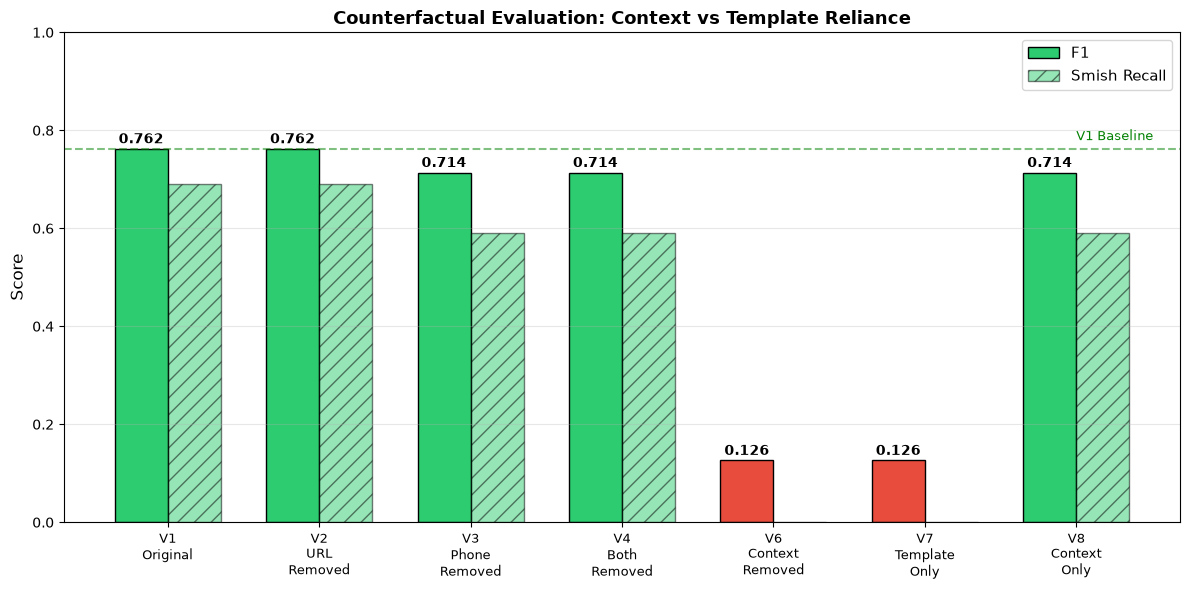

✅ Saved: results/figures/counterfactual_evaluation.png


: 

In [ ]:
# ============================================================
# Counterfactual Bar Chart
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

variants = ['V1\nOriginal', 'V2\nURL\nRemoved', 'V3\nPhone\nRemoved', 
            'V4\nBoth\nRemoved', 'V6\nContext\nRemoved', 'V7\nTemplate\nOnly', 
            'V8\nContext\nOnly']
f1_scores = [0.7623, 0.7623, 0.7138, 0.7138, 0.1262, 0.1262, 0.7138]
smish_recall = [0.6898, 0.6898, 0.5912, 0.5912, 0.0000, 0.0000, 0.5912]

colors = ['#2ECC71' if f > 0.70 else '#F39C12' if f > 0.50 else '#E74C3C' 
          for f in f1_scores]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(variants))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='F1', 
                color=colors, edgecolor='black')
bars2 = ax.bar(x + width/2, smish_recall, width, label='Smish Recall',
                color=colors, alpha=0.5, edgecolor='black', hatch='//')

for bar, f in zip(bars1, f1_scores):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Counterfactual Evaluation: Context vs Template Reliance', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(variants, fontsize=9)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

# Add annotations
ax.axhline(0.7623, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(len(variants)-1, 0.78, 'V1 Baseline', color='green', fontsize=9)

plt.tight_layout()
plt.savefig("results/figures/counterfactual_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/figures/counterfactual_evaluation.png")

In [1]:
train_model(
    model_name="google/muril-base-cased",
    tag="muril_lora_r16",
    r=16
)

NameError: name 'train_model' is not defined